## 🏪 RETAIL & LOGISTICS PYTHON ANALYTICS
### Phase 2 — EDA + Visualisations
#### Dataset: Superstore Sales (Kaggle)
#### Stakeholder: Analytics Lead

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

### Step 1: Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('../super_store_dataset/superstore.csv',encoding = 'latin-1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Step 2: Clean fix the dataset

In [4]:
# fix dtypes
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

print(f"dtype: {df.dtypes}")

dtype: Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [5]:
df['shipping_days'] = (df['Ship Date'] - df['Order Date']).dt.days
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


### Step 3: EDA + Visualization


### QUESTION 1
#### Stakeholder: "Break down total sales by Category and Region and visualise it. Which category drives the most revenue and is any region significantly outperforming the others?"


In [7]:
# Revenue by Region and Category
quaterly_review = df.groupby(['category','region'])['sales'].sum().reset_index()
quaterly_review.columns = ['category', 'region', 'total_revenue']
quaterly_review

,category,region,total_revenue
0,Furniture,Central,163797.1638
1,Furniture,East,208291.2040
2,Furniture,South,117298.6840
3,Furniture,West,252612.7435
4,Office Supplies,Central,167026.4150
5,Office Supplies,East,205516.0550
6,Office Supplies,South,125651.3130
7,Office Supplies,West,220853.2490
8,Technology,Central,170416.3120
9,Technology,East,264973.9810


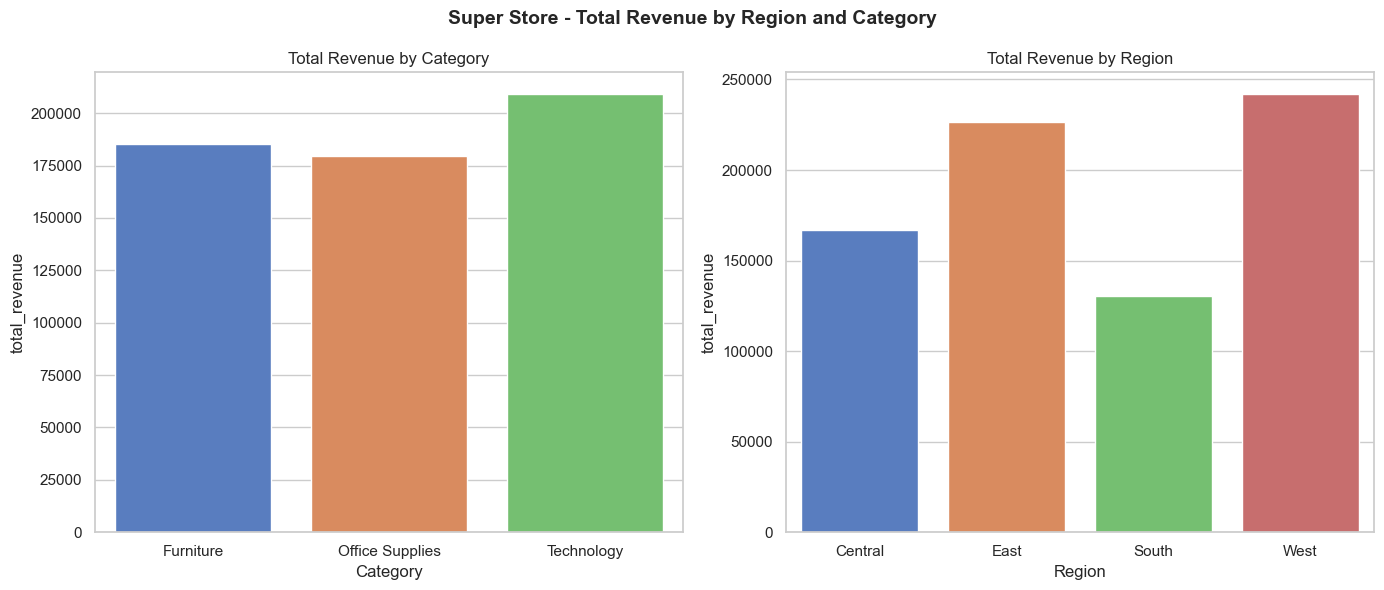

In [8]:
# Visualizing Revenue by Region and Category

fig, axes = plt.subplots(1,2,figsize=(14,6))

sns.barplot(data=quaterly_review, x='category', y='total_revenue', hue='category', palette='muted',ax=axes[0],legend=False, errorbar=None)
axes[0].set_title('Total Revenue by Category')
axes[0].set_xlabel('Category')

sns.barplot(data=quaterly_review, x='region',y='total_revenue', hue='region', palette='muted',ax=axes[1],legend=False, errorbar=None)
axes[1].set_title('Total Revenue by Region')
axes[1].set_xlabel('Region')

plt.suptitle('Super Store - Total Revenue by Region and Category', fontsize= 14, fontweight='bold')
plt.tight_layout()
plt.show()

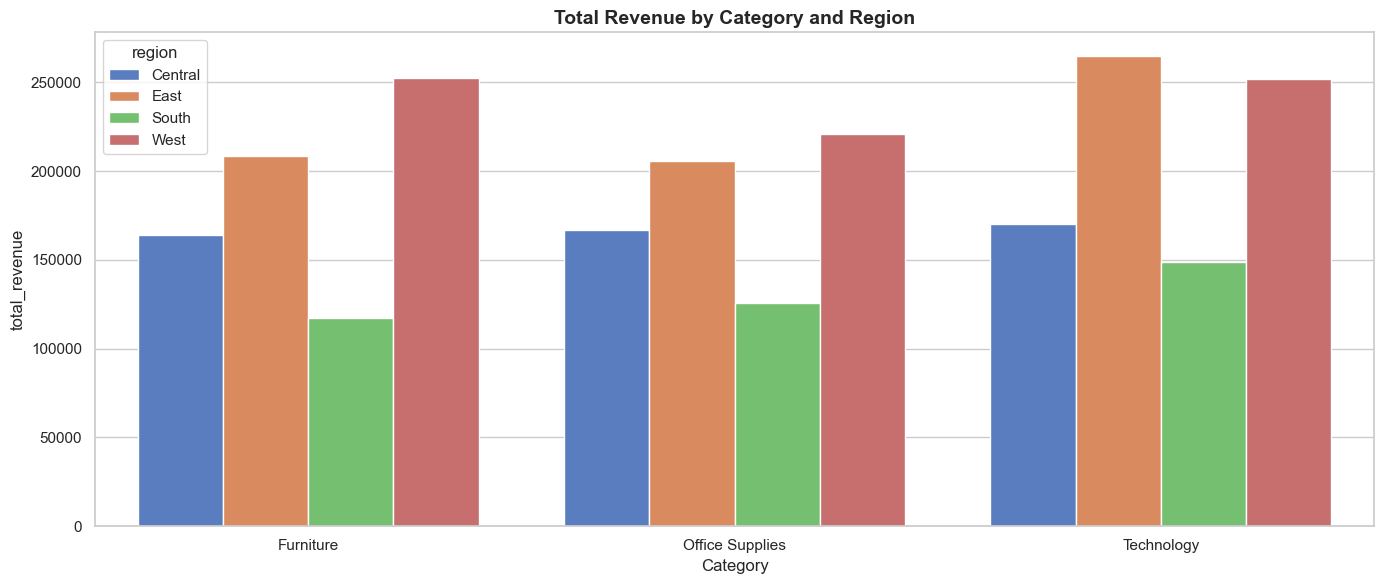

In [9]:
# Visualizing Revenue by Region and Category in single chart

plt.figure(figsize=(14,6))
sns.barplot(data=quaterly_review, x='category', y='total_revenue', hue='region',palette='muted')
plt.xlabel('Category')
plt.title('Total Revenue by Category and Region', fontsize = 14, fontweight='bold')
plt.tight_layout()
plt.show()

### Findings:
##### Technology + East is strongest combination at ~$265K
##### Furniture + South is weakest at ~$117K
##### West is consistently strong across all categories

### QUESTION 2
#### Stakeholder: "I suspect heavy discounting is hurting us. Show me the relationship between discount and profit with a regression line and give me the correlation number."

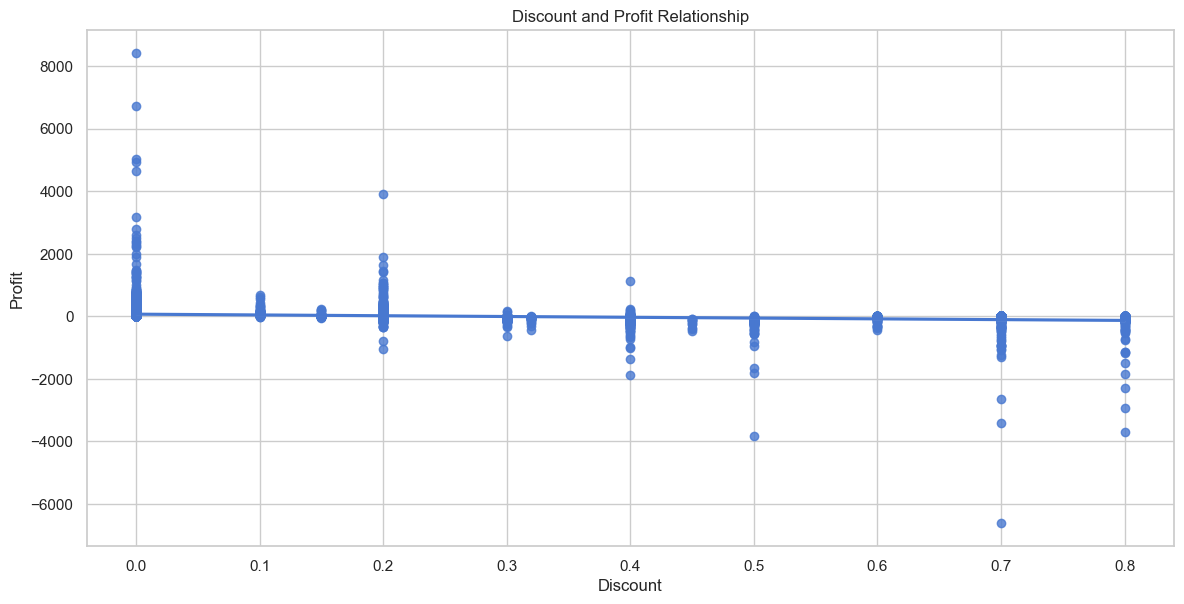

In [10]:
# Relationship between Discount and Profit

plt.figure(figsize=(12,6))
sns.regplot(x='discount', y='profit', data=df)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.title('Discount and Profit Relationship')
plt.show()

In [11]:
# Correlation 
df[['discount','profit']].corr()

,discount,profit
discount,1.000000,-0.219487
profit,-0.219487,1.000000


### Finding:
##### Correlation = -0.22 (weak negative relationship)
##### Profit goes clearly negative when discount hits 0.4+
##### Business insight: Discounts above 40% are a direct hit on profit

### QUESTION 3
#### Stakeholder: "Show me a pairplot of sales, profit, discount, and quantity. I want to see if anything jumps out before we model it."

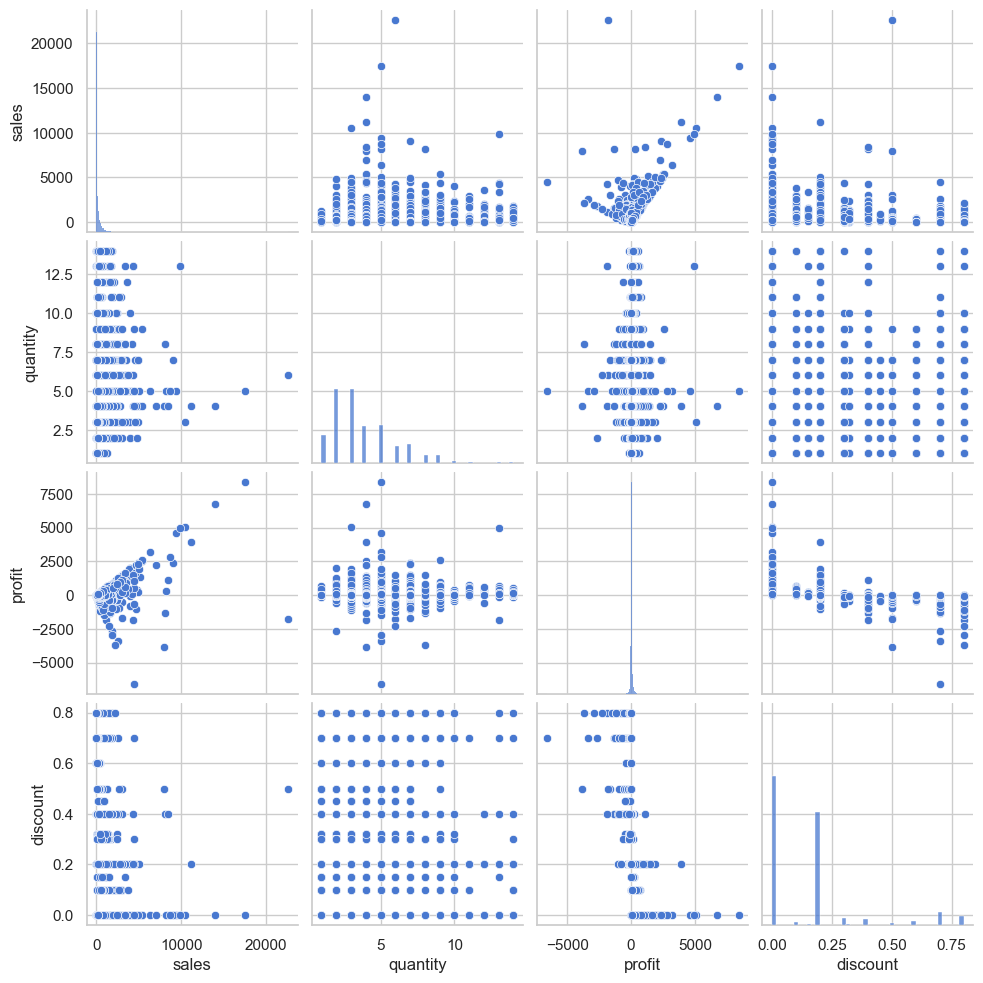

In [12]:
# finding relation - sales, profit, discount and quantity

cols = ['sales','quantity', 'profit','discount']
df_subset = df[cols]

sns.pairplot(df_subset)
plt.savefig('../super_store_dataset/01_key_metrics.png',dpi=150)
plt.show()

### Findings:
##### Sales vs Profit: positive relationship — higher sales tend to mean higher profit
##### Discount vs Profit: as discount increases profit drops and goes negative
##### Sales distribution: heavily right skewed — most orders are small value


### QUESTION 4
#### Stakeholder: "Which segment is most profitable relative to its sales volume? Show me sales and profit side by side for each customer segment."

In [13]:
# Impact of Consumer Segment on Business

consumer_seg = df.groupby('segment')[['sales', 'profit']].sum().reset_index()
consumer_seg

,segment,sales,profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


In [14]:
seg_melted = pd.melt(
    consumer_seg, 
    id_vars = 'segment',
    value_vars=['sales', 'profit'],
    var_name='metric',
    value_name='value'
)

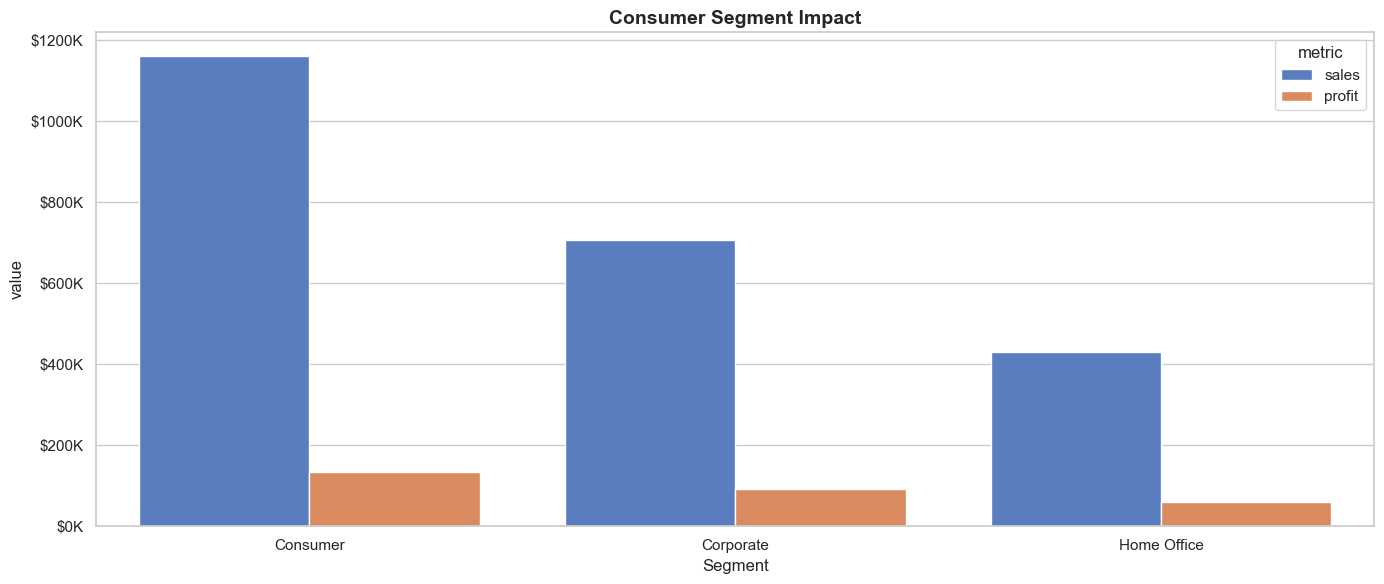

In [15]:
plt.figure(figsize=(14,6))
sns.barplot(data=seg_melted, x='segment',y='value', hue='metric')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)
plt.title('Consumer Segment Impact', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.tight_layout()
plt.savefig('../super_store_dataset/02_consumer_segment_impact.png', dpi=150)
plt.show()

In [16]:
consumer_seg['profit_margin'] = round(
    consumer_seg['profit'] / consumer_seg['sales'] * 100, 2
)
print(consumer_seg)

       segment         sales       profit  profit_margin
0     Consumer  1.161401e+06  134119.2092          11.55
1    Corporate  7.061464e+05   91979.1340          13.03
2  Home Office  4.296531e+05   60298.6785          14.03


### Finding:
##### Consumer has highest absolute profit ($134K)
##### Home Office has highest profit margin at 14.03%
##### Corporate sits in the middle at 13.03%
##### Insight: Home Office orders are less discounted and more efficient

### QUESTION 5
#### Stakeholder: "Show me profit distribution — is it normal? Are there loss-making orders I should know about before modelling?"

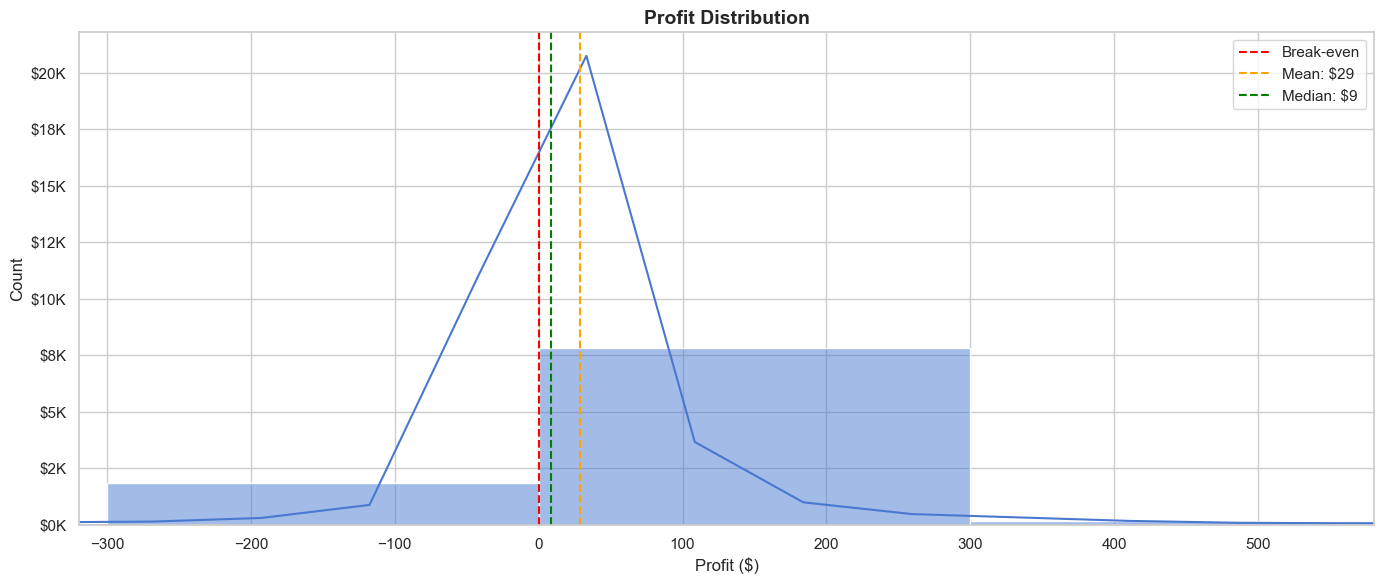

In [17]:
# KDE distribution of proit
plt.figure(figsize=(14, 6))
sns.histplot(data=df, x='profit', kde=True, bins=50)
plt.axvline(0, color='red',linestyle='--', label='Break-even')
plt.axvline(df['profit'].mean(), color = 'orange', linestyle='--',
            label=f'Mean: ${df["profit"].mean():.0f}')
plt.axvline(df['profit'].median(), color='green', linestyle='--',
            label=f'Median: ${df["profit"].median():.0f}')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))   

# Zoom in on the central 98% of the data
plt.xlim(df['profit'].quantile(0.01), df['profit'].quantile(0.99))

plt.title('Profit Distribution', fontsize = 14, fontweight='bold')
plt.xlabel('Profit ($)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()                       
plt.show()

In [36]:
loss_pct = round((df['profit'] < 0).sum() * 100 / len(df), 2)
print(f'Loss-making orders: {loss_pct}%')

Loss-making orders: 18.72%


### Finding:
##### Distribution is left skewed
##### 18.72% of orders are loss-making
##### Bulk of orders sit just above break-even
##### Insight: Small changes in discounting could push more orders into loss territory

### QUESTION 6
#### Stakeholder: "Which sub-categories are hurting us? Show me total profit by sub-category and highlight loss-making ones in a different colour."

In [19]:
# profit by subcategory

sub_cat_profit = df.groupby('sub-category')['profit'].sum().sort_values(ascending=False).reset_index()
sub_cat_profit

,sub-category,profit
0,Copiers,55617.8249
1,Phones,44515.7306
2,Accessories,41936.6357
3,Paper,34053.5693
4,Binders,30221.7633
5,Chairs,26590.1663
6,Storage,21278.8264
7,Appliances,18138.0054
8,Furnishings,13059.1436
9,Envelopes,6964.1767


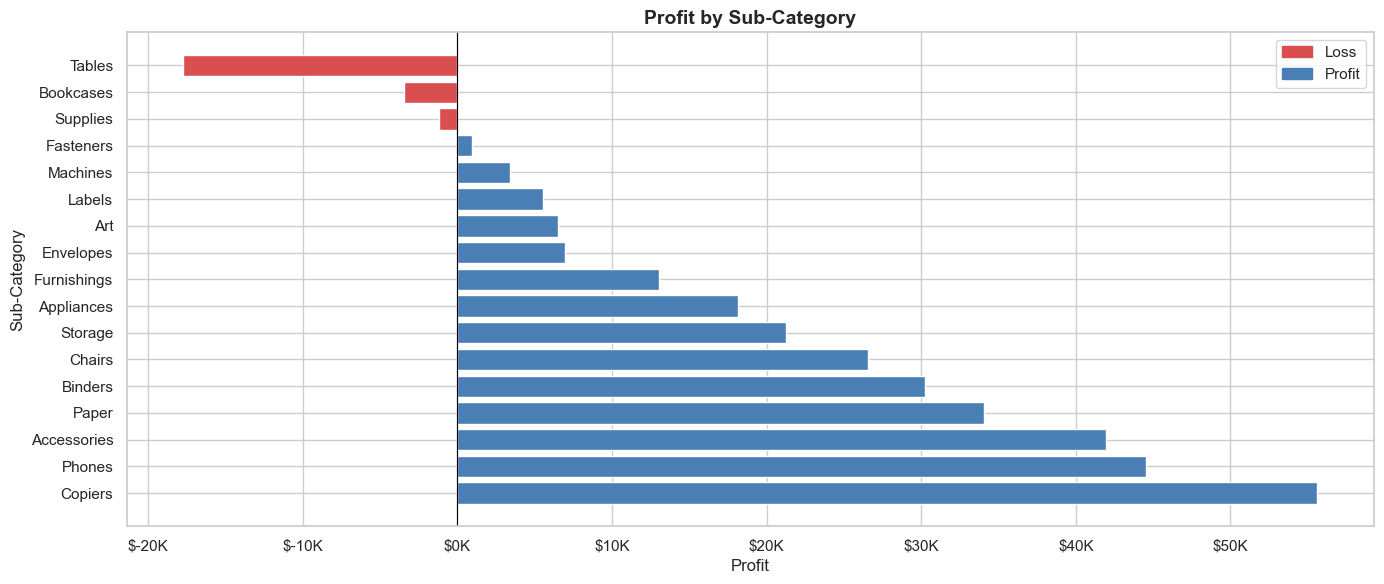

In [20]:
colors = ['#d94f4f' if x < 0 else '#4a7fb5'
            for x in sub_cat_profit['profit']]

plt.figure(figsize=(14,6))

plt.barh(sub_cat_profit['sub-category'],sub_cat_profit['profit'],color = colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _:f'${x/1000:.0f}K'))

legend = [Patch(color='#d94f4f', label='Loss'),
        Patch(color='#4a7fb5', label='Profit')]
plt.legend(handles=legend)        

plt.title('Profit by Sub-Category', fontsize=14, fontweight='bold')
plt.ylabel('Sub-Category')
plt.xlabel('Profit')
plt.tight_layout()
plt.savefig('../super_store_dataset/04_profit_by_category.png',dpi=150)
plt.show()

In [21]:
sub_cat_profit['profit_pct'] = round(sub_cat_profit['profit'] * 100.0 / sub_cat_profit['profit'].sum(), 2)
sub_cat_profit

,sub-category,profit,profit_pct
0,Copiers,55617.8249,19.42
1,Phones,44515.7306,15.54
2,Accessories,41936.6357,14.64
3,Paper,34053.5693,11.89
4,Binders,30221.7633,10.55
5,Chairs,26590.1663,9.28
6,Storage,21278.8264,7.43
7,Appliances,18138.0054,6.33
8,Furnishings,13059.1436,4.56
9,Envelopes,6964.1767,2.43


### Finding:
##### 3 loss-making sub-categories:
##### Tables:    -$17,725 (-6.19% of total profit)
##### Bookcases: -$3,472  (-1.21% of total profit)
##### Supplies:  -$1,189  (-0.42% of total profit)
##### Combined loss: ~7.8% of total profit eroded
##### Insight: Investigate discounting on Tables specifically

In [22]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,state,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


### QUESTION 7
#### Stakeholder: "Show me monthly sales trend with a 3-month rolling average. Is there seasonality or growth we should factor into forecasting?"

In [32]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['year_month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('year_month')['sales'].sum().reset_index()
monthly_sales.head()
print(monthly_sales['year_month'].dtype)


period[M]


In [33]:
monthly_sales['year_month_dt'] = monthly_sales['year_month'].dt.to_timestamp()
monthly_sales['rolling_avg'] = monthly_sales['sales'].rolling(3).mean()
print(monthly_sales.head())

  year_month      sales year_month_dt   rolling_avg
0    2014-01  14236.895    2014-01-01           NaN
1    2014-02   4519.892    2014-02-01           NaN
2    2014-03  55691.009    2014-03-01  24815.932000
3    2014-04  28295.345    2014-04-01  29502.082000
4    2014-05  23648.287    2014-05-01  35878.213667


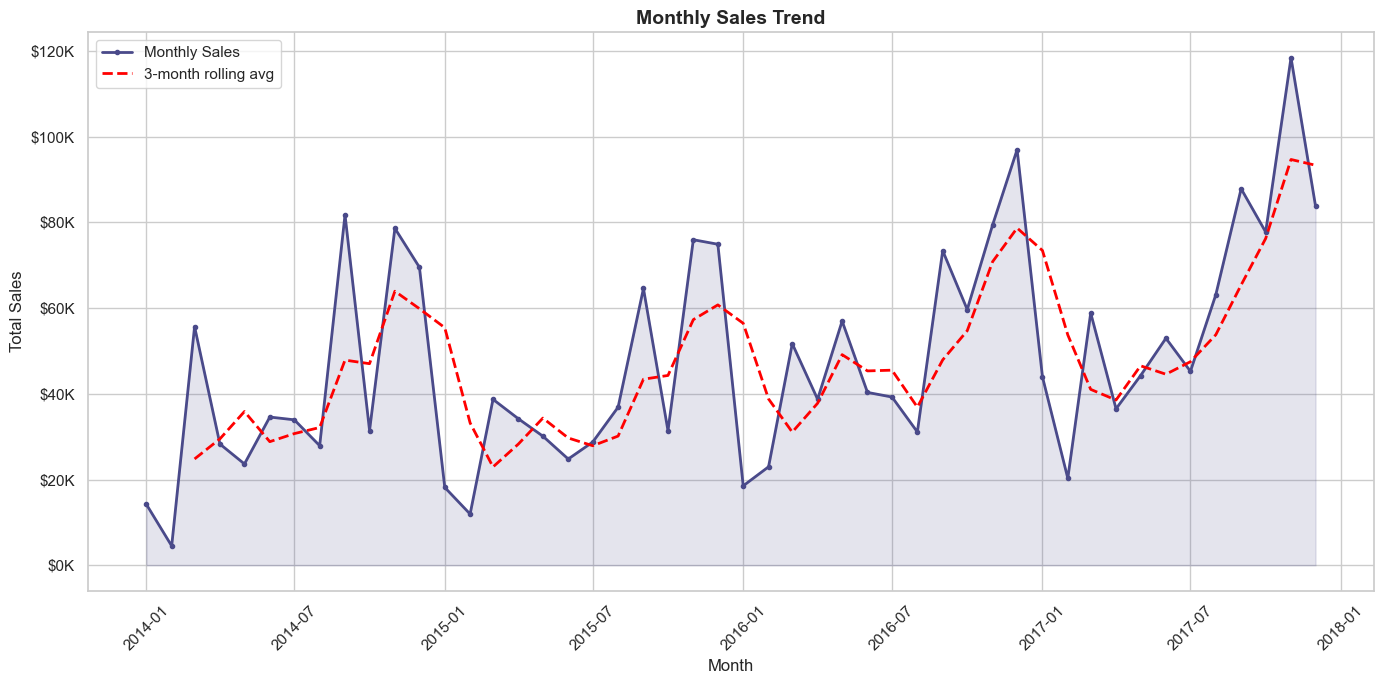

In [34]:
# Monthly Sales Trend Line Chart

fig, ax = plt.subplots(figsize=(14,7))

ax.plot(monthly_sales['year_month_dt'], monthly_sales['sales'], color = '#4a4a8a', linewidth=2, marker='o', markersize=3,
            label='Monthly Sales')

ax.fill_between(monthly_sales['year_month_dt'], monthly_sales['sales'], alpha=0.15, color='#4a4a8a')

ax.plot(monthly_sales['year_month_dt'], monthly_sales['rolling_avg'], color = 'red', linewidth=2, linestyle='--',
            label='3-month rolling avg')

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}K')
)

ax.set_title('Monthly Sales Trend', fontsize = 14, fontweight= 'bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../super_store_dataset/05_monthly_sales_trend.png', dpi=150)
plt.show()

### Finding:
##### Clear Q4 seasonality — November/December peaks every year
##### Highest single month ~$120K in late 2017
##### Predictable post-holiday dip every January/February
##### Strong year-on-year growth trend — each year's peak higher than last
##### Insight: Scale inventory and logistics capacity ahead of Q4 every year